In [ ]:
# 구글 마운트 해 주세요.

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

image_path =  '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/8기/컴퓨터비전_AI응용/data/copy.png'

In [2]:
image_path

'/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/8기/컴퓨터비전_AI응용/data/copy.png'

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
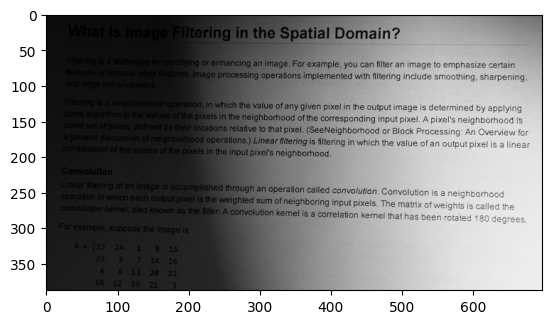

In [3]:
cv2.imread(image_path)

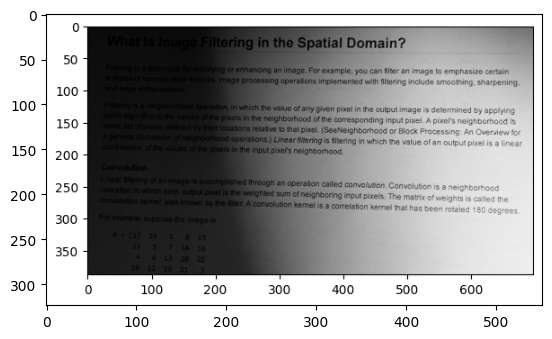

In [5]:
image = cv2.imread(image_path)
plt.imshow(image)
plt.show()

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
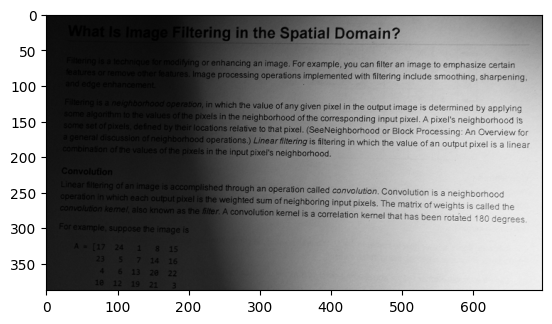

In [7]:
# 이진화 : 흑백 [0, 255] 채널로 이미지를 변경
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray

In [8]:
# 임계값 (threshold)
cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

(50.0,
 array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], dtype=uint8))

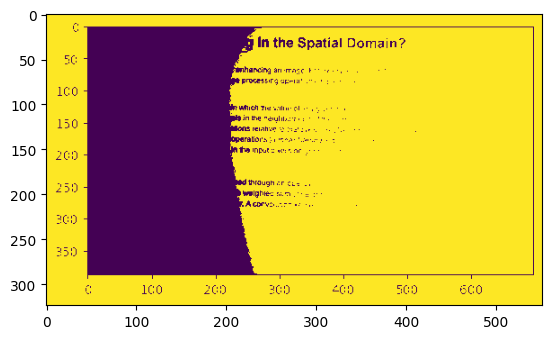

In [10]:
result, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
# 50 (threshold) 임계값 (50보다 어두우면 검정, 밝으면 흰색)
plt.imshow(binary)
plt.show()

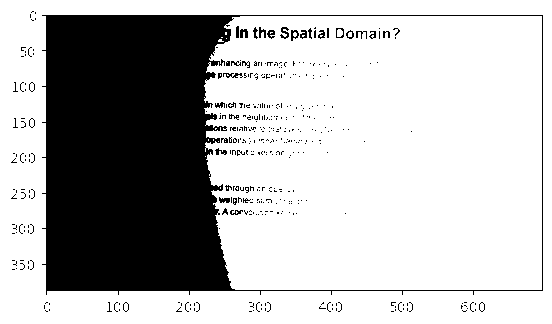

In [11]:
cv2_imshow(binary)

적응형 이진화
- 영역(region) 마다 다른 임계값 사용하겠다는 의미

cf) 일반적으로 이진화 : 동일 기준(threshold)

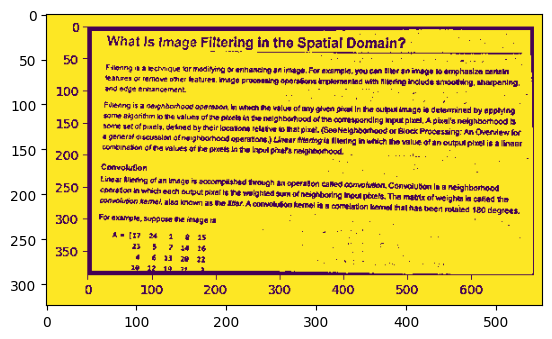

In [13]:
binary_ad = cv2.adaptiveThreshold(
            gray,   # 적용할 이미지
            255,    # 최대값
            cv2.ADAPTIVE_THRESH_MEAN_C,    # 평균값 적용
            # 옵션(적응형의 판단 기준) 주변 픽셀들의 가중평균(가우시안)
            cv2.THRESH_BINARY,  # 임계값 적용
            # 주어진 조건(threshold 임계치)에 맞으면 결과를 이렇게 해줘 (흰색, 검은색)
            11,          # kernel 크기 (블록 크기, 주변 영역 크기)
            4            # 상수(평균/가중평균에서 빼는 값)

        )

plt.imshow(binary_ad)
plt.show()

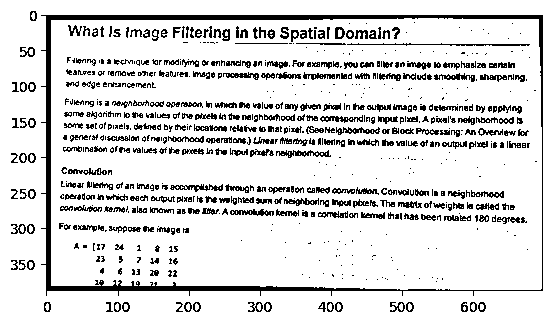

In [14]:
cv2_imshow(binary_ad)

수행단계
- (11*11) 커널 가져오세요. 주변 픽셀 값 가져오기
- (옵션) cv2.ADAPTIVE_THRESH_MEAN_C 활용, 주변 픽셀에 가우시안 평균 적용 >> 평균 계산
- 여기서 나온 평균값에서 상수(4) 뺀 값을 threshold T로 사용
- 픽셀 값이 T 보다 크면 >> 흰색 (255)
- 픽셀 값이 T 보다 작으면 >> 검은색 (0)
- C 상수 : 값이 크면 >> threshold 낮아짐 >> 더 밝게 잡힘
- 활용분야: 로봇 라인트레이싱(line tracing), OCR, 자동차번호판 인식(조명변화에 강해요)

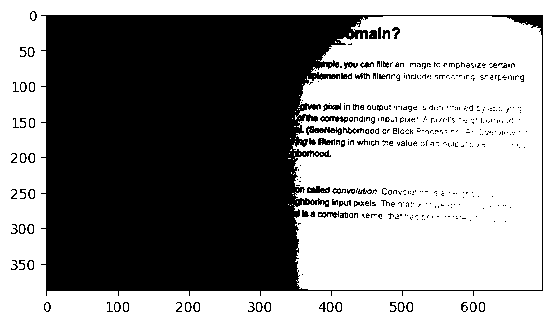

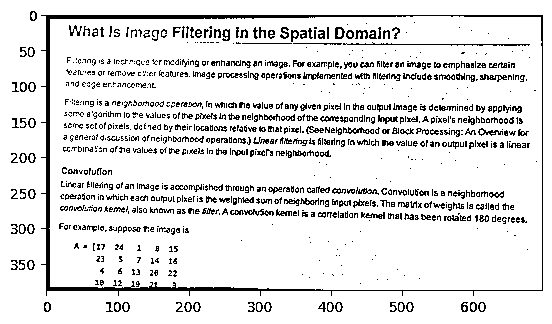

In [16]:
ret, binary_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
binary_ad = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 4)

cv2_imshow(binary_global) # 검은 부분 생기거나 깨짐
cv2_imshow(binary_ad)      # 글자/라인 선명하게 추출

# 어디까지 전처리할거니?
# 1) 이미지 불러와서 이진화(흑백 변환)
# 2) 적응형 임계값 (threshold) 처리


엣지 검출

In [18]:
# sobel filter
# 1차 미분, slope(gradient)
# 영상 밝기 변화량 (gradient)계산 >> 물체 윤곽선(contour), 경계(edge) 추출하는 필터
# 밝기가 급격하게 변하네 >> 경계(edge)네 (vs) 변화없네 >> 배경이네
# >> 경계의 방향과 강도 계산

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
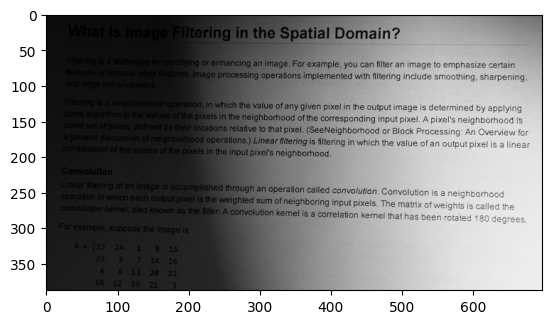

In [19]:
image

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
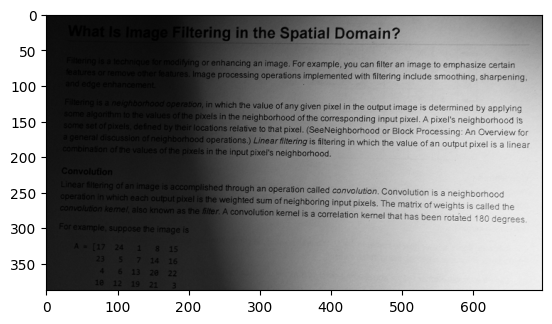

In [20]:
gray

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
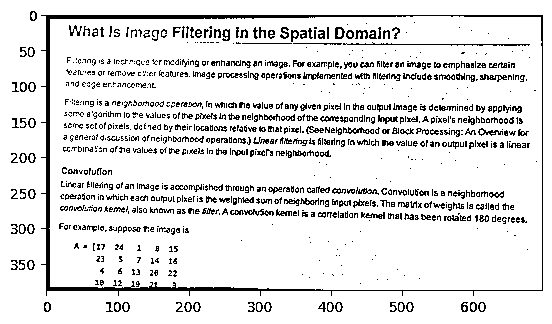

In [21]:
binary_ad

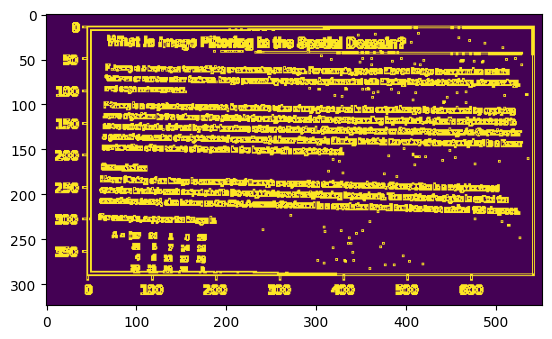

In [24]:
# sobel filter 적용
# 1. 0 >> 수평 엣지, 1 >> 수직 엣지
# ksize : kernel size

gx = cv2.Sobel(binary_ad, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(binary_ad, cv2.CV_32F, 0, 1, ksize=3)

# binary_ad : 적응형 이진화 거친 이미지 가져와요
# gx(x방향) : 가로 변화 감지 >> 세로선 찾기
# >> dx = 1 x축 방향으로 미분 / dy=0 y축 방향으로 미분 안해(수직 엣지)
# gy(y방향) : 세로 변화 감지 >> 가로선 찾기
# >> dx = 0 x축 방향으로 미분 안 해 / dy=1 y축 방향으로 미분(수평 엣지)
# cv2.CV_32F: 32 bit 실수형(실수는 음수도 포함하니깐 아주 정밀하게 계산할거야)
# cf) uint8 (일반이미지) openCV, matplotlib 일반이미지로 인식(0~255)

# 필터를 이용해서 엣지 강도 추출
mag = cv2.magnitude(gx, gy)
# print(mag)
# 피타고라스 정리 활용 >> 전체 엣지 강도 계산 mag = sqrt(gx^2 + gy^2)
# gx (x 방향 기울기, 밝기 변화량). gy(y방향 기울기, 밝기 변화량)
# >> 경계 방향은 상관없어. 얼마나 강한 경계(edge) 있는지 계산

mag = np.uint8(np.clip(mag, 0, 255))
# np.clip(mag, 0, 255) mag 부분을 이미지로 표현 ([0, 255] 범위로 표현하도록 강제)
plt.imshow(mag)
plt.show()

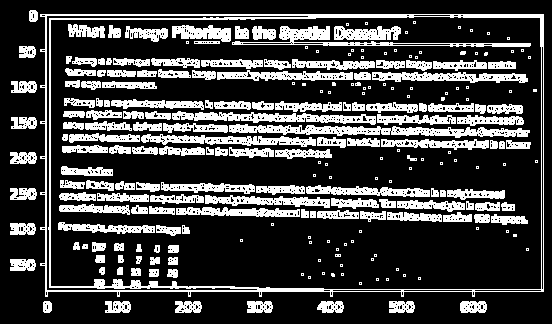

In [25]:
cv2_imshow(mag)

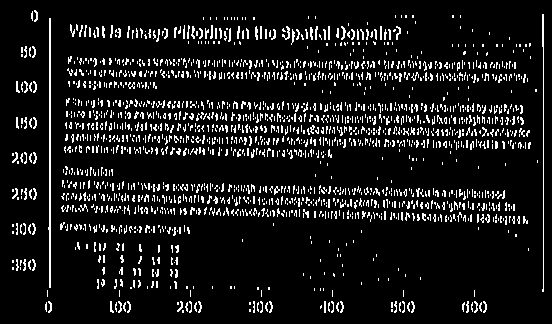

In [26]:
cv2_imshow(gx)

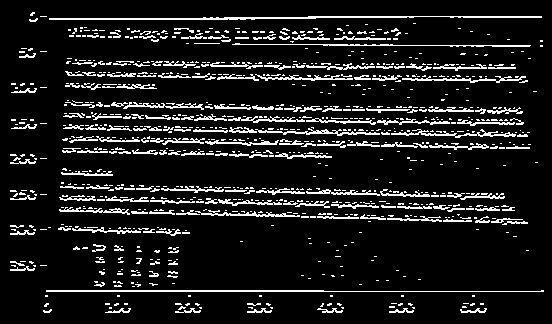

In [27]:
cv2_imshow(gy)

Canny 필터
- Canny(적용할 이미지, 낮은 임계값, 높은 임계값)

Canny filter 동작방식
1) 노이즈 제거(Gaussian Blur)
2) gradient 계산(Sobel Filter)
3) 비최대억제(NMS: Non-Maximum Suppression) 엣지의 방향을 따라서 로컬의 최대값만 남기고 나머지는 억제
4) 이중임계값 처리(Double Thresholoding) 강한 엣지, 약한 엣지를 파악 >> 약한 엣지는 제거, 강한 엣지는 살려
5) 애매한 애들은? 강한 엣지와 연결된 애도 살려줘.


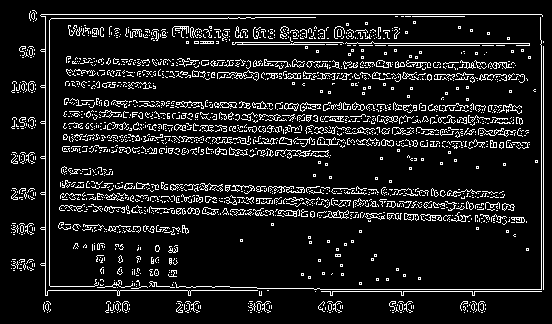

In [30]:
result = cv2.Canny(binary_ad, 30, 200)
# 30: 낮은 임계값 (약한 엣지)
# 200: 높은 임계값 (강한 엣지)
# 3-200 사이 (애매한 구간에 있는 값)
# >> 강한 엣지와 연결되면 살아남음
cv2_imshow(result)

코너 (모서리) 검출 알고리즘
- 해리스 코너(코너) 알고리즘
- 시 토마스 알고리즘

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
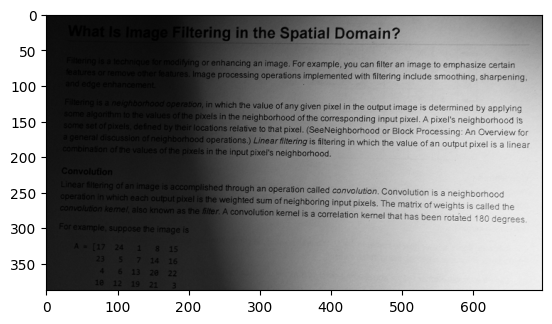

In [31]:
gray

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
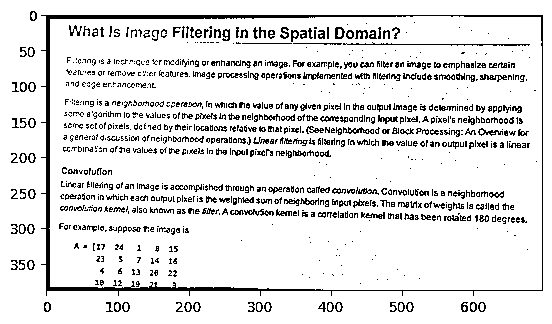

In [32]:
binary_ad

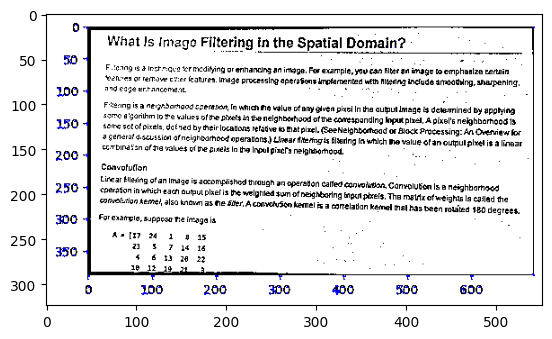

In [44]:
# 해리스 코너 검출
# 윈도우를 모든 방향으로 움직였을 때, pixel 값의 변화가 가장 큰 지점을 코너로 간주함
# 모서리 찾기
# 두 방향(x, y) 모두 강한 밝기 변화량이 존재하는 곳(특징점 추출)
# 코너(선과 선이 교차하는 곳) 저기가 코너일 가능성이 얼마나 높지?
# 점수(score) 맵(map)
# >> score가 높으면 코너일 가능성이 높음

harris = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.04)
# print(harris)

# np.float32(gray) : gradient 계산(미분 계산: 변화량 축정
# > 미분하면 음수도 나올 수 있음(실수로 변환) 원래 이미지(uint8 >> float32)
# blockSize=2 (2*2) 주변 영역 검사
# >> 코너 점(point) 계산 할 때 고려하는 주변 영역 크기
# ksize = 3 : 3*3 커널로 gradient 계산
# k=0.04 민감도(threshold 임계치) 조절 (0.04-0.06)
# k가 클수록 더 민감하게 반응 >> 코너가 더 많이 검출

# 정규화
# 검출결과를 0-255 범위로 정규화 (uint8)
# 왜 정규화 해요?
# >> 해리스 검출 결과가 점수맵(score map)이기 때문에
# 값범위가 매우 크거나 음수가 될 수 있기 때문에 0-255 압축 표현
harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# harris_norm = (harris-min(harris)) / (max(harris) - min(harris)) * 255

corner = cv2.cvtColor(binary_ad, cv2.COLOR_BGR2RGB)

# 임계값 필터링
corner[harris_norm > 0.3*harris_norm.max()] = (0, 0, 255)
# 상위 70% 강한 코너만 rgb 중 blue 로 표시

plt.imshow(corner)
plt.show()

goodFeaturesToTrack
- 해리스 코너 개선 알고리즘

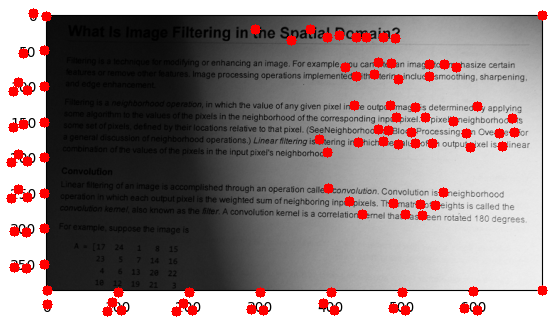

In [52]:
# 흑백변환 >> 알고리즘 적용 >> 시각화

src = cv2.imread(image_path)
gray =cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

# 알고리즘 적용: goodFeaturesToTrack
# - 실무용
# - 해리스 코너 : 점수맵(score map) : 사용자가 직접 임계치(threshold) 설정
# - goodFeaturesToTrack 는 해리스코너 점수 계산한 뒤, 점수정렬, 임계치 필터링, 거리 필터링 자동화

# 노이즈 제거 위한 가우시안 블러 처리 추가 작업
gray_gauss = cv2.GaussianBlur(gray, (5, 5), 0)

# 추적하기 좋은 특징점 찾기
pts = cv2.goodFeaturesToTrack(
    gray_gauss,
    maxCorners=100 ,    # 최대 100개 특징점
    qualityLevel=0.01, # 상위 1%만
    minDistance=10    # 특징점 간 최소거리 10px
)
# print(pts)
# 3차원 배열
if pts is not None:
    # pts = pts.astype(np.uint8) # 좌표 값이 255 넘으면 값 깨짐
    # float 좌표를 점수 좌표로 변환
    pts = np.int64(pts)
    for i in pts:
        x, y = i.ravel() # 3차원 >> 1차원으로 펼쳐줘
        cv2.circle(src, (x, y), 5, (0, 0, 255), -1)

# 시각화 할 때 BGR >> RGB로 변경
cv2_imshow(src)

허프 변환 (Hough Transform)
- 직선 검출 가능
- 원 검출가능

In [54]:
np.around(1.54).astype(np.uint8)

np.uint8(2)

In [55]:
image_path =  '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/8기/컴퓨터비전_AI응용/data/water_coins.jpg'

array([[[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [245, 250, 249],
        [246, 251, 250],
        [246, 251, 250]],

       [[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [246, 251, 250],
        [246, 251, 250],
        [247, 252, 251]],

       [[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [246, 251, 250],
        [246, 251, 250],
        [247, 252, 251]],

       ...,

       [[205, 214, 211],
        [224, 233, 230],
        [225, 234, 231],
        ...,
        [242, 247, 245],
        [242, 247, 245],
        [242, 247, 245]],

       [[199, 208, 205],
        [218, 227, 224],
        [220, 229, 226],
        ...,
        [241, 246, 244],
        [241, 246, 244],
        [241, 246, 244]],

       [[193, 202, 199],
        [212, 221, 218],
        [215, 224, 221],
        ...,
        [240, 245, 243],
        [240, 245, 243],
        [240, 245, 243]]], dtype=uint8)
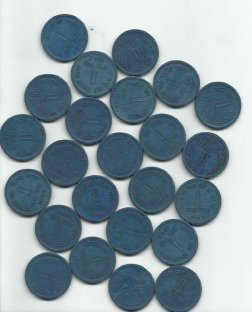

In [56]:
image = cv2.imread(image_path)
image

In [57]:
image.shape

(312, 252, 3)

array([[234, 239, 242, ..., 249, 250, 250],
       [234, 239, 242, ..., 250, 250, 251],
       [234, 239, 242, ..., 250, 250, 251],
       ...,
       [212, 231, 232, ..., 246, 246, 246],
       [206, 225, 227, ..., 245, 245, 245],
       [200, 219, 222, ..., 244, 244, 244]], dtype=uint8)
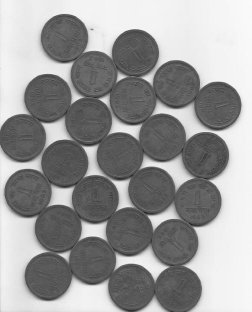

In [58]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray

(1, 24, 3)


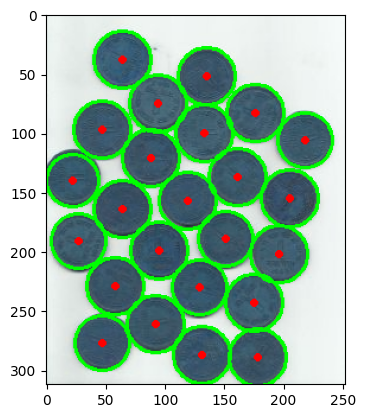

In [61]:
# 원(동전) 검출

circles=\
cv2.HoughCircles(gray,                 # 이진화된 이미지(흑백)
                 cv2.HOUGH_GRADIENT,   # 기울기를 사용해서 원 찾을래
                 dp=1.2,               # 해상도 scaling 비율(1.0 입력 이미지와 같은 해상도)
                                       # >> 값이 크면 속도 빠르면 정확도(성능) 저하
                 minDist=30,           # 검출된 원(중심) 사이 최소 거리
                                       # >> 원 중심 간 거리 간격이 30 이하 >> 중복이 아니다
                 param1=100,           # 높은 임계값 (canny edge upper threshold)
                 param2=30,            # 투표(voting) 누적 임계값(원이라고 판단할 기준)
                 minRadius=10,         # 최소 반지름
                 maxRadius=50)         # 최대 반지름

print(circles.shape)
# (1, 24, 3)
# voting (투표) 많은 점(pts) 이 원을 지지하면 원으로 인정

if circles is not None:
    circles = np.around(circles).astype(np.uint16)

    for (x, y, r) in circles[0,:]:
        # 원 그림에서 배열의 첫번째 차원(1) 무시
        # circles.shape 3차원 배열 (1, 24, 3)
        # 즉 (1, N, 3) >> 무시하면 2차원 (N, 3) 여기서는 (24, 3)
        # 여기서 첫번째 차원 1 : 항상 크기가 1 (배치가 1인 것과 유사)
        # 세번째 차원(3) 3가지 정보 (0: 원의 중심 x좌표, 1:원의 중심 y좌표, 2: 원의 반지름 r)
        # 검출된 모든 원(n개) 정보만 선택
        cv2.circle(image, (x, y), r, (0, 255, 0), 2)
        # 원의 중심좌표(x,y) 반지름 r은 허프변환으로 찾아낸 반지름, 2: 선의 두께
        cv2.circle(image, (x, y), 2, (255, 0, 0), 2)


plt.imshow(image)
plt.show()


In [ ]:
# minDist=30,
# 검출된 원(중심) 사이 최소거리
# >> 원 중심간 간격이 30 이상 >> 중복 아니다(별개의 원이라 인정하겠다)
# >> 목적: 과잉 검출 방지
# 30 pixel 거리 이내 다른 원의 중심을 허용 하지 않겠다.
# 즉, 하나의 원에 대한 하나의 검출 결과만 보장한다
# 값이 작으면 서로 가까운 원들을 개별적인 원으로 검출 >> 비슷한 원 여러개가 잡힘
# 값이 크면 원이 너무 멀리 떨어진 경우에만 검출


# param2 = 30,         # 투표(voting) 누적 임계값(원이라고 판단할 기준)
# 값이 높으면 (누가봐도) 원이야 하는 확실한 원만 검출
# 값이 낮으면 (아닌거 같은데) 약한 원도 검출

array([[234, 239, 242, ..., 249, 250, 250],
       [234, 239, 242, ..., 250, 250, 251],
       [234, 239, 242, ..., 250, 250, 251],
       ...,
       [212, 231, 232, ..., 246, 246, 246],
       [206, 225, 227, ..., 245, 245, 245],
       [200, 219, 222, ..., 244, 244, 244]], dtype=uint8)
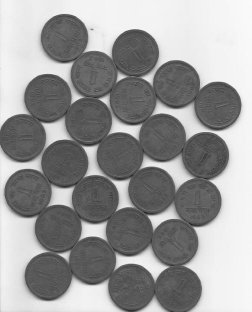

In [62]:
gray

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
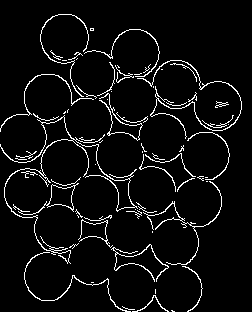

In [63]:
# canny edge 검출
edges = cv2.Canny(gray, 50, 150)
edges
# edge 있으면 흰색(255), 없으면 검정(0)

ρ = x*cos (θ) + y*sin (θ)

In [82]:
# 확률적 직선 검출
# 이미지 edge(경계)에서 직선(lines) 자동 검출 알고리즘
# >> 실제 길이 선분 형태로 반환(실무)
# >> 시작점(x1, y1), 끝점(x2, y2) 좌표로 이루어진 배열 출력

# cf. cv2.HoughLines 무한 직선 형태
# HoughLinesP P(probability) 확률



In [83]:
image_path =  '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/8기/컴퓨터비전_AI응용/data/water_coins.jpg'
image = cv2.imread(image_path)

array([[[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [245, 250, 249],
        [246, 251, 250],
        [246, 251, 250]],

       [[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [246, 251, 250],
        [246, 251, 250],
        [247, 252, 251]],

       [[229, 236, 233],
        [234, 241, 238],
        [237, 244, 241],
        ...,
        [246, 251, 250],
        [246, 251, 250],
        [247, 252, 251]],

       ...,

       [[205, 214, 211],
        [224, 233, 230],
        [225, 234, 231],
        ...,
        [242, 247, 245],
        [242, 247, 245],
        [242, 247, 245]],

       [[199, 208, 205],
        [218, 227, 224],
        [220, 229, 226],
        ...,
        [241, 246, 244],
        [241, 246, 244],
        [241, 246, 244]],

       [[193, 202, 199],
        [212, 221, 218],
        [215, 224, 221],
        ...,
        [240, 245, 243],
        [240, 245, 243],
        [240, 245, 243]]], dtype=uint8)
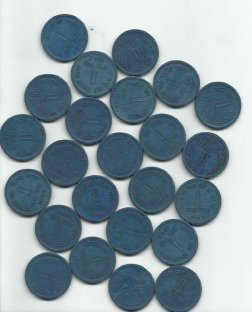

In [66]:
image

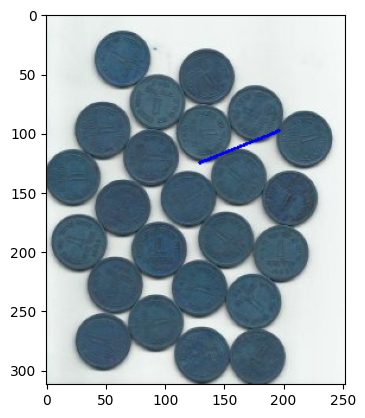

In [84]:
# 흑백 변환 >> 엣지 검출 >> 직선 검출
from cv2.gapi import threshold

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# canny edge 검출
edges = cv2.Canny(gray, 50, 150)

# 확률적 직선 검출
lines =\
cv2.HoughLinesP(
    edges,               # 캐니엣지검출된 엣지 모음
    rho = 1,             # 해상도
    theta = np.pi/180,   # 해상도(각도)
    threshold = 10,      # 직선으로 간주될 수 있는 최소값(default)
    minLineLength = 50,  # 내가 검출하려고 하는 직선의 최소 길이
    maxLineGap = 10      # 직선으로 간주되는 간격
)
# rho : 원점(0,0) 에서 직선까지 거리 (1px 단위로 정밀 계산)
# theta : 각도 단위(radian)
# >> np.pi/180 = 1도 (degree)
# >> 각도 resolution 크면 직선 검출 정확도가 떨어짐
# threshold = 10 # 직선으로 간주될 수 있는 최소값(최소 투표수 10)
# >> 누적 투표 수가 10 이상은 되어야 선이라고 간주
# >> 높이면 확실한 직선만 검출(노이즈 적어짐) 낮추면 작은 선들도 다 검출
# minLineLength 내가 검출하려고 하는 직선의 최소 길이(기준 미만 이면 무시)
# maxLineGap = 10      # 직선으로 간주되는 간격(직선 간격 허용)
# >> 중간에 끊어져 있는 선들이 있어요. 선 들 간 간격이 10이하면 연결된 하나의 선으로 간주

# 시각화
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.imshow(image)

In [85]:
image_path =  '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/8기/컴퓨터비전_AI응용/data/lines.png'

In [86]:
image_path

'/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/8기/컴퓨터비전_AI응용/data/lines.png'

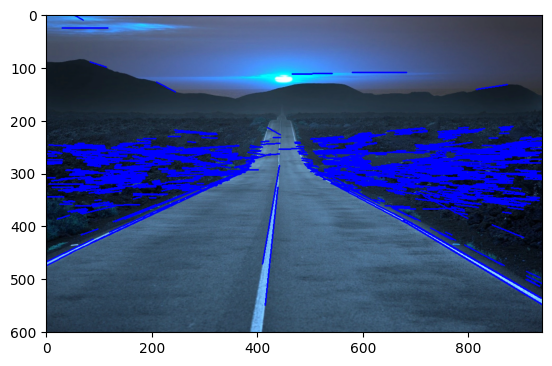

In [87]:
# 흑백 변환 >> 엣지 검출 >> 직선 검출
from cv2.gapi import threshold

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# canny edge 검출
edges = cv2.Canny(gray, 50, 150)

# 확률적 직선 검출
lines =\
cv2.HoughLinesP(
    edges,               # 캐니엣지검출된 엣지 모음
    rho = 1,             # 해상도
    theta = np.pi/180,   # 해상도(각도)
    threshold = 100,      # 직선으로 간주될 수 있는 최소값(default)
    minLineLength = 10,  # 내가 검출하려고 하는 직선의 최소 길이
    maxLineGap = 10      # 직선으로 간주되는 간격
)
# rho : 원점(0,0) 에서 직선까지 거리 (1px 단위로 정밀 계산)
# theta : 각도 단위(radian)
# >> np.pi/180 = 1도 (degree)
# >> 각도 resolution 크면 직선 검출 정확도가 떨어짐
# threshold = 10 # 직선으로 간주될 수 있는 최소값(최소 투표수 10)
# >> 누적 투표 수가 10 이상은 되어야 선이라고 간주
# >> 높이면 확실한 직선만 검출(노이즈 적어짐) 낮추면 작은 선들도 다 검출
# minLineLength 내가 검출하려고 하는 직선의 최소 길이(기준 미만 이면 무시)
# maxLineGap = 10      # 직선으로 간주되는 간격(직선 간격 허용)
# >> 중간에 끊어져 있는 선들이 있어요. 선 들 간 간격이 10이하면 연결된 하나의 선으로 간주

# 시각화
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.imshow(image)

컨투어(Contour, 윤곽선) 검출

In [89]:
# list comprehension

[x for x in range(10)]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [91]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [92]:
sample = []

for i in range(10):
    sample.append(i)

print(sample)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


OTSU : 자동으로 최적 임계값 찾기
- grayscale image >> 이진화 하는 코드
- 히스토그램(pixel 값 분포) 자동으로 분석 >> 최적의 임계값 (threshold) >> 이미지 내부에서 흑(0), 백(255) 나눠줘요
- 문서스캔, OCR

In [93]:
image_path =  '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/8기/컴퓨터비전_AI응용/data/water_coins.jpg'
image = cv2.imread(image_path)

array([[234, 239, 242, ..., 249, 250, 250],
       [234, 239, 242, ..., 250, 250, 251],
       [234, 239, 242, ..., 250, 250, 251],
       ...,
       [212, 231, 232, ..., 246, 246, 246],
       [206, 225, 227, ..., 245, 245, 245],
       [200, 219, 222, ..., 244, 244, 244]], dtype=uint8)
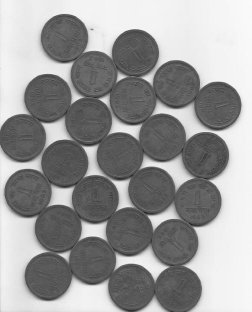

In [95]:
# 흑백 >> 임계값으로 컨투어(윤곽선) 검출

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray

In [96]:
# 임계값 적용
cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
# 162.0 : OTSU 가 자동으로 찾아 준 최적의 임계값

(162.0,
 array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], dtype=uint8))

In [99]:
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

cv2.RETR_LIST
- 윤곽선 검색 방식(contour retrieval mode)
  - RETR_LIST : 모든 윤곽선 찾아서 리스트로 반환
  - RETR_EXTERNAL : 가장 바깥 윤곽선만
  - RETR_TREE : 윤곽선 계층구조까지 (부모-자식)
  - RETR_CCOMP : 2단계 계층구조까지

- cv2.CHAIN_APPROX_NONE
  - 윤곽선의 모든 점을 전부 저장
- cv2.CHAIN_APPROX_SIMPLE
  - 꼭 필요한 점(시작점, 끝점)만 저장

In [103]:
# 컨투어(윤곽선) 검출
# cv2.RETR_EXTERNAL 윤곽선을 찾아내는 방법
# cv2.CHAIN_APPROX_SIMPLE 윤곽선 저장하는 방법

cons = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
# binary : 임계값 자동 적용(OTSU가 자동 생성) 나온 이진화된 이미지
# cv2.RETR_LIST (retrieve list 목록을 검색하다) (모든 윤곽선 검색해 봐요)
# cv2.CHAIN_APPROX_NONE 모든 점 저장
# 흰색(255) 영역의 경계선 찾아요 >> 리스트 형식으로 반환

# print(cons)
con_packs = cons[0] if len(cons) == 2 else cons[1]
# print(con_packs)

# openCV 3.X (contours, hierachy) (윤곽선 리스트, 계층 정보)
# openCV 4.X (contours)

(array([[[153, 299]],

       [[152, 300]],

       [[151, 301]],

       [[150, 302]],

       [[149, 303]],

       [[149, 304]],

       [[148, 305]],

       [[147, 306]],

       [[146, 307]],

       [[145, 308]],

       [[144, 308]],

       [[143, 309]],

       [[142, 310]],

       [[141, 310]],

       [[140, 311]],

       [[139, 311]],

       [[138, 311]],

       [[139, 311]],

       [[140, 311]],

       [[141, 311]],

       [[142, 311]],

       [[143, 311]],

       [[144, 311]],

       [[145, 311]],

       [[146, 311]],

       [[147, 311]],

       [[148, 311]],

       [[149, 311]],

       [[150, 311]],

       [[151, 311]],

       [[152, 311]],

       [[153, 311]],

       [[154, 311]],

       [[155, 311]],

       [[156, 311]],

       [[157, 311]],

       [[158, 311]],

       [[159, 311]],

       [[160, 311]],

       [[161, 311]],

       [[162, 311]],

       [[163, 311]],

       [[164, 311]],

       [[165, 311]],

       [[166, 311]],

       [[

In [105]:
cons[:1][0]

(array([[[153, 299]],
 
        [[152, 300]],
 
        [[151, 301]],
 
        [[150, 302]],
 
        [[149, 303]],
 
        [[149, 304]],
 
        [[148, 305]],
 
        [[147, 306]],
 
        [[146, 307]],
 
        [[145, 308]],
 
        [[144, 308]],
 
        [[143, 309]],
 
        [[142, 310]],
 
        [[141, 310]],
 
        [[140, 311]],
 
        [[139, 311]],
 
        [[138, 311]],
 
        [[139, 311]],
 
        [[140, 311]],
 
        [[141, 311]],
 
        [[142, 311]],
 
        [[143, 311]],
 
        [[144, 311]],
 
        [[145, 311]],
 
        [[146, 311]],
 
        [[147, 311]],
 
        [[148, 311]],
 
        [[149, 311]],
 
        [[150, 311]],
 
        [[151, 311]],
 
        [[152, 311]],
 
        [[153, 311]],
 
        [[154, 311]],
 
        [[155, 311]],
 
        [[156, 311]],
 
        [[157, 311]],
 
        [[158, 311]],
 
        [[159, 311]],
 
        [[160, 311]],
 
        [[161, 311]],
 
        [[162, 311]],
 
        [[163, 3

In [106]:
cons[1]

array([[[ 1, -1, -1, -1],
        [ 2,  0, -1, -1],
        [ 3,  1, -1, -1],
        [ 4,  2, -1, -1],
        [ 5,  3, -1, -1],
        [ 6,  4, -1, -1],
        [ 7,  5, -1, -1],
        [ 8,  6, -1, -1],
        [ 9,  7, -1, -1],
        [10,  8, -1, -1],
        [11,  9, -1, -1],
        [12, 10, -1, -1],
        [13, 11, -1, -1],
        [14, 12, -1, -1],
        [15, 13, -1, -1],
        [-1, 14, -1, -1]]], dtype=int32)

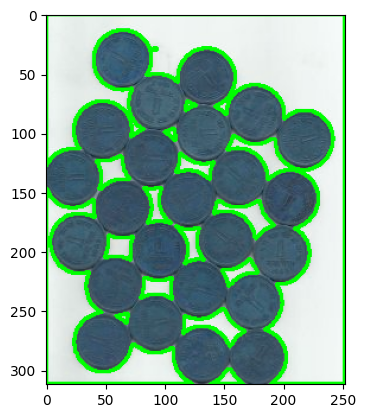

In [107]:
# 시각화
cv2.drawContours(image, con_packs, -1, (0, 255, 0), 2)
# -1: 모든 윤곽선 그려줘
plt.imshow(image)
plt.show()

In [108]:
# eos

In [ ]:
# [정리 시간]
# 1. cv2.moments
# >> moments: 이미지에서 '중심' 어디지? '면적'얼마지? >> 데이터 수치 추출
# 2. cv2.addWeighted : 두 영상이 겹쳐져요. '잔상효과''레이어 쌓기' 등 >> 새로운 이미지 만들어요
# >> dst = w1 * img1 + w2 * img2 + gamma
# 배경 위에 반투명, 투명한 레이어(UI) 올리거나 두 영상을 특징 결합시 사용
# 3. cv2.magnitude (벡터의 크기)
# >> 엣지(경계) 검출, optical flow(광학 흐름)에 자주 사용
# >> 변화의 세기 mag = sqrt(gx^2 + gy^2)
# >> 각 pixel 위치 확인 >> x방향 변화량 + y방향 변화량 합쳐서 '얼마나 강한 경계선(엣지)인가?'

In [ ]:
# binary_ad
# 어디까지 전처리한거야?
# 1) 이미지 불러와서 이진화(흑백 변환)
# 2) 적응형 임계값(threshold) 처리
# 여기까지 전처리 한 이미지(입력값)로 canny 엣지 검출

In [ ]:
# ksize와 blocksize 차이가 뭐예요?
# ksize : 필터, 마스크의 크기
# (반드시 홀수만 가능: 중심점 계산해야 하기 때문 좌우/상하 차이구해야함)  3*3, 5*5 등
# blocksize : adaptiveThreshold 같이 적응형 기반 계산 하기 위함 (주변 영역의 이웃의 크기)
# 즉 평균 구할 영역의 크기